## Fingerprinting Demo

The objective of this demo is to demonstrate the core functionality of our solution. Here, you will find how to achieve the following:

1. Configure the system
2. Load the dataset
3. Train (or load) the model
4. Pick a few rounds of signal from the captured "epochs" (aka rounds)
5. Run the newly obtained signal through the system and:
    1. Enroll the device as a new entry for monitoring OR
    2. Update an existing device entry

In [1]:
%reload_ext autoreload
%autoreload 2

import matlab
import utils
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI

2024-10-20 22:50:09.834722: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-20 22:50:09.834770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-20 22:50:09.836178: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-20 22:50:09.843538: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-20 22:50:10.562620: W tensorflow/compiler/tf2

### 1. Configure the system

Here, we define all the system-critical parameters and initialize our API.

In [4]:
ROOT_DIRECTORY = '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY = '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting/lora_rffi_working'
MATLAB_SESSION_ID = 'fp_workflow'
AUG_ON = False

DATA_CONFIG = {
    'dataset_name': DatasetAPI.DATASET_V2,
    'frame_count_train': 200, # 200 for v2, 500 for v3
    'frame_count_epoch': 100,
    'samples_count': 400
}

AUG_CONFIG = {
    'multiplier': 5,
    't_rms_bounds': matlab.double([1, 2]),
    'd_f_bounds': matlab.double([0, 10]),
    'k_factor_bounds': matlab.double([0, 10]),
    'awgn': matlab.double([10, 50]),
}

MODEL_CONFIG = {
    'batch_size': 32,
    # 'loss_type': 'triplet_loss', 'loss_num_neg': 1,
    'loss_type': 'quadruplet_loss', 'loss_num_neg': 2,
    #  'loss_type': 'quintuplet_loss', 'loss_num_neg': 3,
    # 'loss_type': 'n_loss', 'loss_num_neg': 2,
    'npair_type': 'samedev',
    # 'npair_type': 'diffdev',
    'alpha': 1.0, # used only for triple & quadruple loss
    'patience': 10,
    'fp_len': 512,
    'row': 50,
    'col': 14
}

RX_NODES = [DatasetAPI.RX_1, DatasetAPI.RX_2, DatasetAPI.RX_3, DatasetAPI.RX_4]

In [5]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
eval_api = EvaluationAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG, 
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)

### 2. Prepare the model

Here, you can either train a separate model for each of the specified receivers from scratch using pre-loaded dataset, or load pre-trained models from the local storage.

In [8]:
enable_training = False

if enable_training: models, _ = fp_api.train_models()
else: models = fp_api.load_models()

### 3. Try out fingerprinting

This is where we can actually test our method.

The API is very simple: whever you capture some new frames from a particular emitter -- use the function `FingerprintingAPI#new_signal()` to determine whether it's a new or an existing device, and update the database accordingly.

All you need to do at this stage is to provide a list of frames.

In [9]:
# Retrieve a dictionary which can convert an Orbit node name to a node ID (its 0-based index)
grid_node_ids, grid_node_coordinates = utils.generate_grid_node_ids()
rx_dataset_epoch_paths = {}
for rx_id in RX_NODES:
    _, dataset_epoch_paths, _, _, _, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], rx_id, None)
    rx_dataset_epoch_paths[rx_id] = dataset_epoch_paths

### 3.1. Evaluate the value of channel-independent spectrograms

For this, we perform the following steps:

1. Take 1 frame from 10 consecutive epochs (aka rounds) from one TX/RX pair;
2. For each epoch, pick one frame and produce its spectrogram, plot them (stitched together)
3. Convert these spectrograms into channel-independent spectrograms, stitch and also plot them

10 stitched STFT spectrograms for RX 1
10 stitched channel independent spectrograms for RX 1


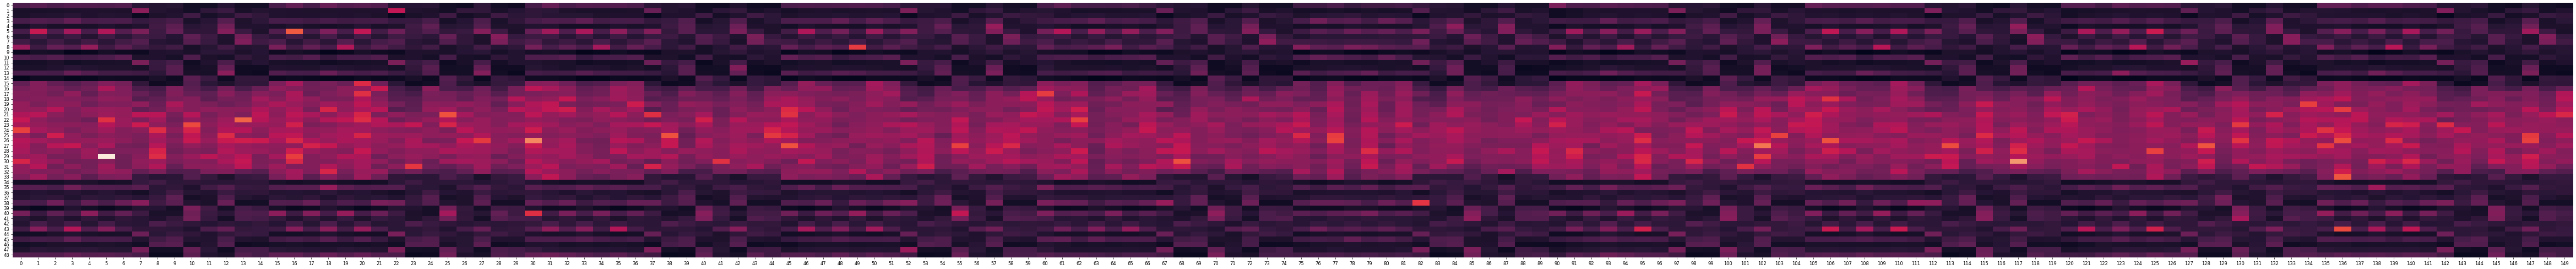

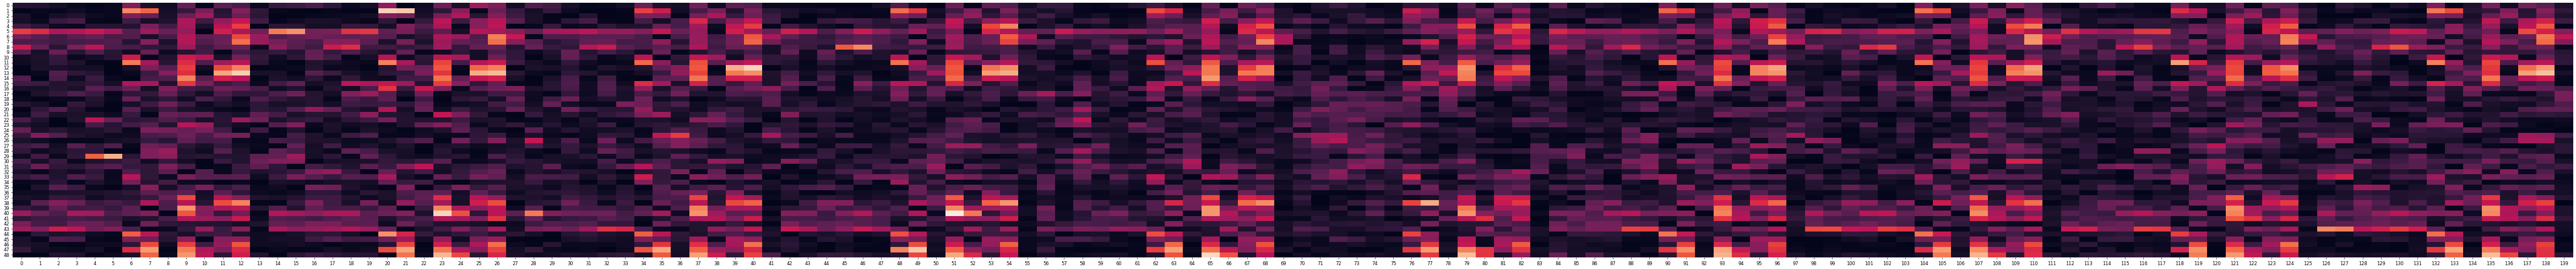

Spectogram values from row 1 (i.e., box 1)
10 stitched STFT spectrograms for RX 1
10 stitched channel independent spectrograms for RX 1


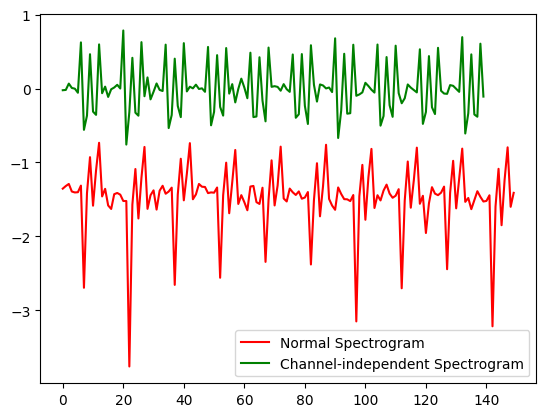

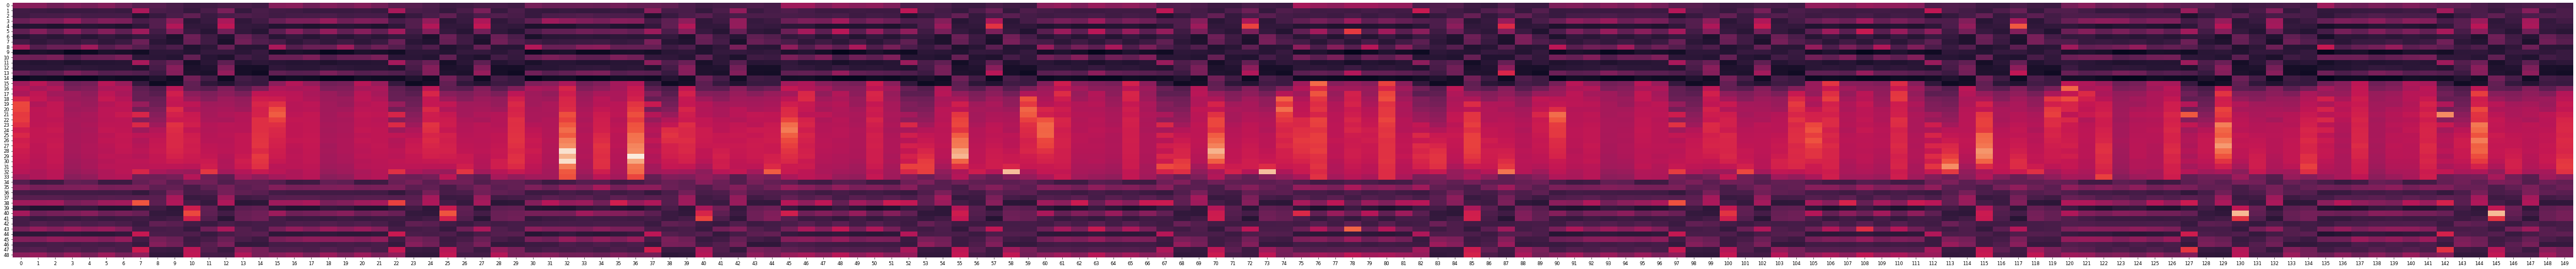

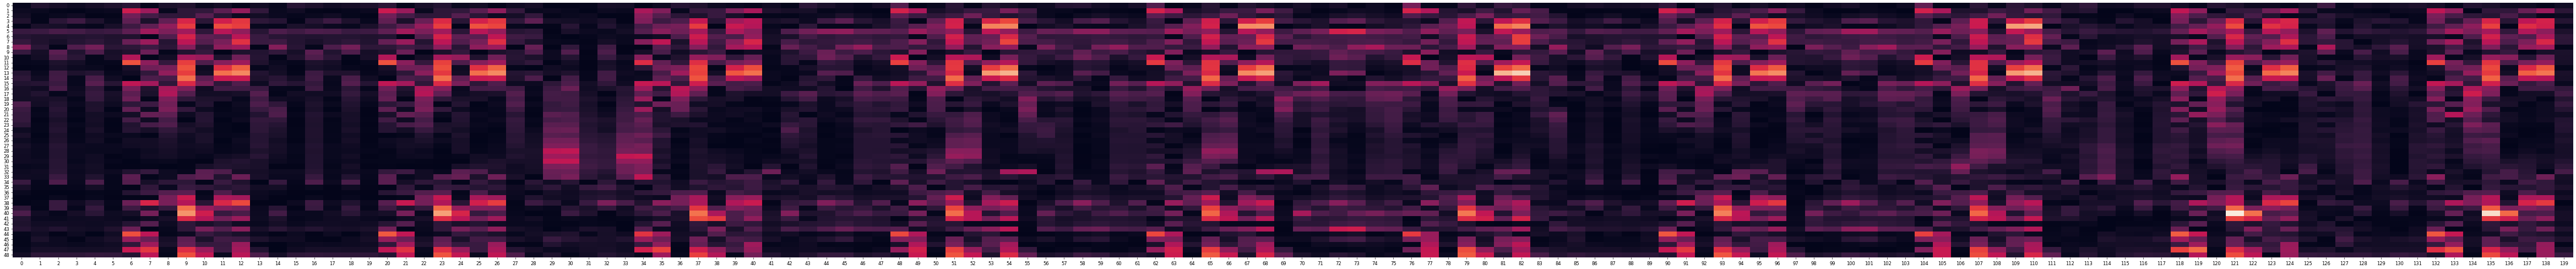

Spectogram values from row 1 (i.e., box 1)
10 stitched STFT spectrograms for RX 1
10 stitched channel independent spectrograms for RX 1


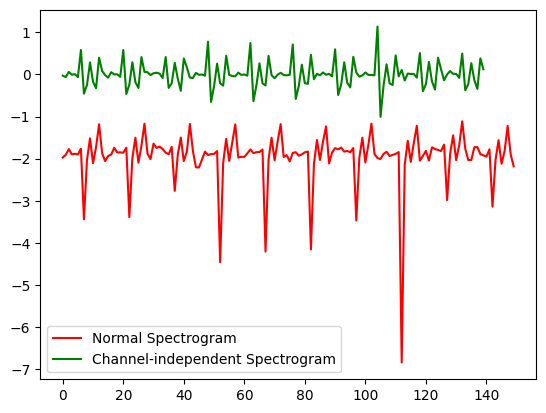

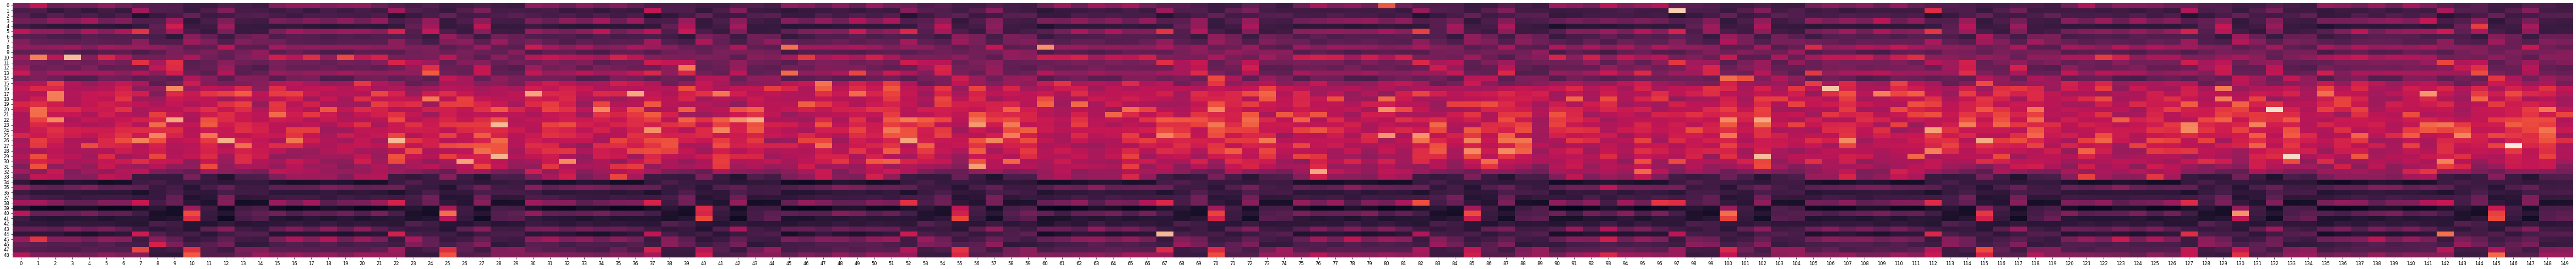

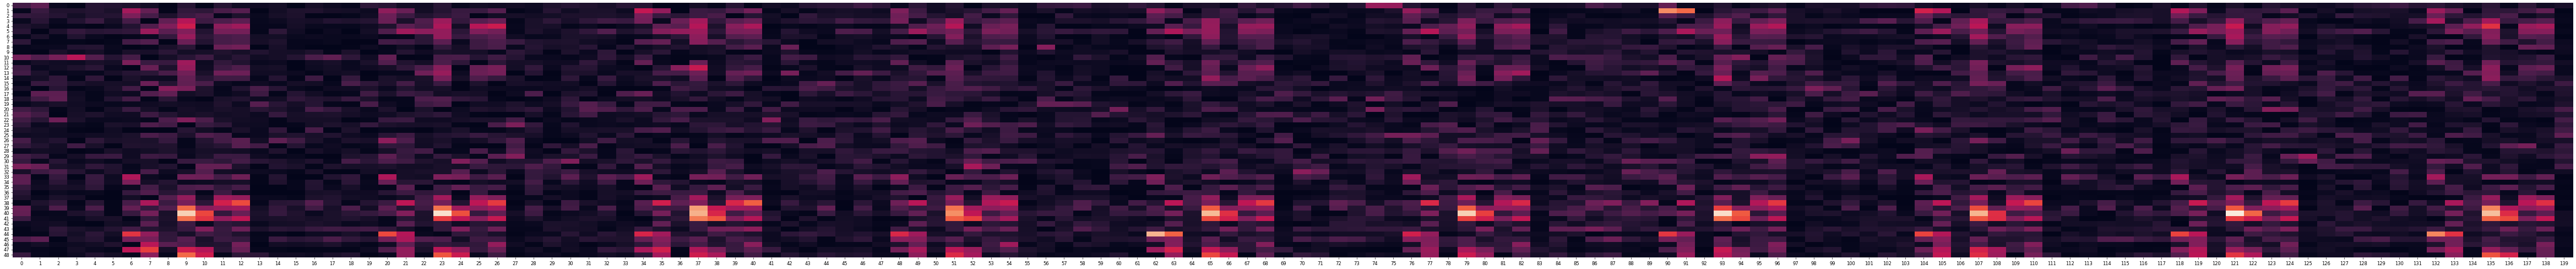

Spectogram values from row 1 (i.e., box 1)


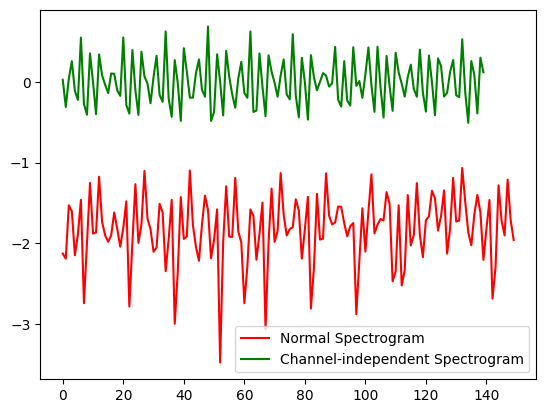

In [81]:
import numpy as np
import seaborn as sea
from dataset_preparation import *
import matplotlib.pyplot as plt

def get_spectrogram(iq, win_len=50, overlap=25):
    data = ChannelIndSpectrogram()._normalization(iq)

    f, t, spec = signal.stft(data, 
                            window='boxcar', 
                            nperseg=win_len, 
                            noverlap=overlap, 
                            nfft=win_len,
                            return_onesided=False, 
                            padded =False, 
                            boundary=None)

    # FFT shift to adjust the central frequency.
    spec = np.fft.fftshift(spec, axes=0)

    spec = np.log10(np.abs(spec)**2)
    
    return spec

def get_channel_independent_spectrogram(spec):
    # Generate channel independent spectrogram.
    chan_ind_spec = spec[:,1:]/spec[:,:-1]    

    # Take the logarithm of the magnitude.      
    chan_ind_spec = np.log10(np.abs(chan_ind_spec)**2)

    return chan_ind_spec

def demo_spec_vs_ind_spec(rx_id, eval_epochs_no):
    eval_frames = []
    for epoch_i in range(1, eval_epochs_no+1):
        frame = dataset_api.load_testing_input(rx_dataset_epoch_paths[rx_id], epoch_idx=epoch_i, device_idx=grid_node_ids['2-20'], frame_count=2)
        eval_frames.append(frame[0]['iq'][0:DATA_CONFIG['samples_count']])

    eval_spec = []
    eval_spec_ind = []
    for frame in eval_frames:
        iq = np.array([frame])
        spec = get_spectrogram(iq).squeeze()
        spec_ind = get_channel_independent_spectrogram(spec).squeeze()

        eval_spec.append(spec)
        eval_spec_ind.append(spec_ind)

    stacked_eval_spec = np.hstack(eval_spec)
    stacked_eval_spec_ind = np.hstack(eval_spec_ind)

    print('10 stitched STFT spectrograms for RX 1')
    plt.figure(figsize=(100, 10), dpi=60)
    sea.heatmap(abs(stacked_eval_spec)[1:, :], cbar=False)

    print('10 stitched channel independent spectrograms for RX 1')
    plt.figure(figsize=(100, 10), dpi=60)
    sea.heatmap(abs(stacked_eval_spec_ind)[1:, :], cbar=False)
    plt.show()

    print('Spectogram values from row 1 (i.e., box 1)')
    plt.plot(stacked_eval_spec[0, :], 'red', label='Normal Spectrogram')
    plt.plot(stacked_eval_spec_ind[0, :], 'green', label='Channel-independent Spectrogram')
    plt.legend()


demo_spec_vs_ind_spec(rx_id = RX_NODES[0], eval_epochs_no=10)
print('=============================')
demo_spec_vs_ind_spec(rx_id = RX_NODES[1], eval_epochs_no=10)
print('=============================')
demo_spec_vs_ind_spec(rx_id = RX_NODES[2], eval_epochs_no=10)

# NOTE: left part are STS, right part are LTS


### 3.1. Retrieve a batch of "newly captured frames" for testing

You can use `DatasetAPI` to retrieve a batch of frames to evaluate the system. To do so, you need to specify the following parameters:
- `dataset_epoch_paths`: list of full system paths to pickle files storing raw signal data for each of the captured epochs within the dataset
- `epoch_idx`: 0-based index of the epoch from which we will take the signal
- `device_idx`: 0-based device index, which can be obtained from the aforementioned dictionary, using Orbit node ID (aka coordinates)
- `frame_count`: number of continuous frames to be used for this particular evaluation

The function returns a list of dict objects, each of them contains data for a single frame:
- `iq`: pre-processed sequence of complex-valued IQ samples
- `rssi`: RSSI value in dB associated with the given frame

Since we configured the Fingerprinting API to work with the `DatasetAPI.DATASET_V2`, you can select the following parameters to test the function:
- `epoch_idx`: any index in the range `[0, 170]` (epochs have approximately 10-15 min gaps between each other)
- `device_idx`: any of the nodes: `2-20`, `12-20`, `14-10`, `15-1`, `16-1`, `16-16`, `17-11`, `20-15`, `20-19`
- `frame_count`: since we specified `frame_count_epoch` to be 100, you can select any number of frames in range `[1, 100]`

In [7]:
frames_rx_all = {}
for rx_id in RX_NODES:
    frames_rx_all[rx_id] = dataset_api.load_testing_input(rx_dataset_epoch_paths[rx_id], epoch_idx=10, device_idx=grid_node_ids['2-20'], frame_count=10)

In [24]:
frames_rx_all['node1-1'][0]['iq'].shape

(1000,)

### 3.2. Process the captured frames

Finally, we can process the frames and determine whether the device we just heard is new or known. 

Here's what the function actually does "under the hood":

1. Initialize a list of device candidates
2. For each receiver:
    1. For each of the frames:
        1. Pick a specified # of samples, optionally apply awgn
        2. Extract fingerprints for each frame
        3. Save RSSI value for each frame
        4. Extract a fingerprint
    2. Aggregate all frames into one input by averaging them across frames
    3. Look up devices from ChromaDB
    4. Do we have any finds:
        1. Yes: add top K neighbors to our candidate list, assign a receiver-specific rank
        2. No:  do nothing
3. For each candidate:
    1. Retrieve fingerprints (vectors) across all receivers
    2. Calculate device candidate weighted distance to our frame
4. Are all distances above the threshold? (or any distances at all)
    1. Yes: this is a new device. Add the corresponding fingerprints to receiver collections
    2. No:  this is a known device. It corresponds to the candidate with the smallest weighted distance
5. Print out the decision: whether it's a new or a known device.

Inputs:
- `frames`: a list of frames which we just retrieved (aka captured), without a label, but all from the same device (we can confirm this using a MAC address, for example)
- `new_device_threshold`: this is the experimentally determined threshold which lets us determine whether we're dealing with a known/unknown device

In [18]:
fp_api.new_signal(frames_rx_all, new_device_threshold=0.55)

1/1 [==============================] - 0s 27ms/step


1/1 [==============================] - 0s 26ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 26ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 28ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


1/1 [==============================] - 0s 38ms/step


Number of requested results 3 is greater than number of elements in index 1, updating n_results = 1


This is a known device. ID: a3b76fec-ef98-4806-ae30-65ce27226d3e


## 4. Evaluate the results

You can run the `FingerprintingAPI#new_signal` function as many times as you'd like -- both on new and previously captured data. The function should either accept the data as new, or associate it with a known entry. So feel free to modify the input arguments to retrieve frames from different devices or epochs (hint: a single device has many epochs, which lets us test how well fingerprints mitigate temporal fluctuations in the environment).

At the end of the experiment, we can run a function to:

1. Explore what's stored in our vector database (ideally, each device should have become a new entry, while existing devices should have only updated existing entries);
2. Render a confusion matrix across known devices using their fingerprints (aka embeddings), w.r.t. each receiver.
    * Note: we don't combine confusion matrices across receivers, since each receiver/frame can have different weight factor.

Since all the relevant parameters are either already encapsulated in the API object, or stored in the database -- the only parameter we can configure is:
* `render_confusion_matrices`: you can disable this feature, if needed.

In [19]:
enrolled_devices = fp_api.list_enrolled_devices(render_confusion_matrices=False)

Total number of unique devices: 1

Device Statistics:
Device ID: a3b76fec-ef98-4806-ae30-65ce27226d3e (added: 2024-09-01T12:47:42.299272, last updated: 2024-09-01T12:48:32.959074)


## 5. Reset the system

Should you need to start over and try the experiment again -- you might need to purge the database to remove known devices. You can do this using the method below.

In [11]:
fp_api.purge_database()

## 6. That's all, folks!

Thank you for exploring our project! If you found this useful, please consider citing our paper. This would mean the world to our team.

![](https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcXhkMmpnZTl0ZmYybWd6NzExMWdxNmY1ZmE4Y2h0d3Zsem96ZG9yMSZlcD12MV9naWZzX3NlYXJjaCZjdD1n/lTpme2Po0hkqI/giphy.gif)

```bibtex
@article{mazokha2024rffi,
  title={RFFI for Mobility Intelligence and MAC Address Derandomization},
  author={Mazokha, Stepan and Bao, Fanchen and Sklivanitis, George and Hallstrom, Jason O},
  journal={TBD},
  year={2024},
  publisher={TBD}
}